## 数据预处理与概览

##  数据预处理与概览

### 数据概览与清洗

In [35]:
import pandas as pd

df = pd.read_csv("train.csv")

# 检查缺失值
missing_values = df.isnull().sum()
total_missing = missing_values.sum()
print(f"共有 {total_missing} 处数据缺失")

# 填补缺失值
if total_missing > 0:
    numeric_columns = df.select_dtypes(include=["number"]).columns
    categorical_columns = df.select_dtypes(exclude=["number"]).columns

    # 数值型字段：用中位数填充
    if len(numeric_columns) > 0:
        df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].median())

    # 分类型字段：用众数填充
    for col in categorical_columns:
        mode_value = df[col].mode()
        df[col].fillna(mode_value[0], inplace=True)


共有 0 处数据缺失


### 描述性统计与目标变量分析

In [38]:
list1 = [
    "age",
    "hours_per_week",
]

print("数值型字段描述性统计：")
print(df[list1].describe())

数值型字段描述性统计：
                age  hours_per_week
count  32561.000000    32561.000000
mean      38.581647       40.437456
std       13.640433       12.347429
min       17.000000        1.000000
25%       28.000000       40.000000
50%       37.000000       40.000000
75%       48.000000       45.000000
max       90.000000       99.000000


In [40]:
counts = df['income'].value_counts()
total = counts.sum()
summary = pd.DataFrame({
    'income': counts.index,
    'Count': counts.values,
    'Percentage': counts.div(total).mul(100)  
})
print("收入频次统计")
print(summary.to_string(index=False))

收入频次统计
income  Count  Percentage
 <=50K  24720   75.919044
  >50K   7841   24.080956


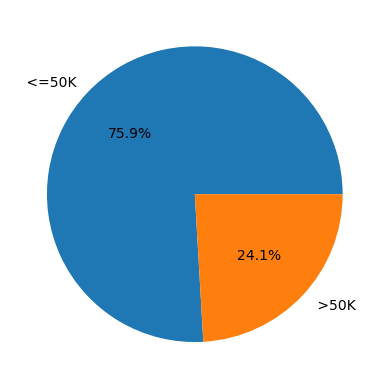

In [42]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots()
counts = df["income"].value_counts()
axes.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
)
plt.show()

## 指定子主题分析

### 教育与工作付出的关系

相关系数: 0.1481


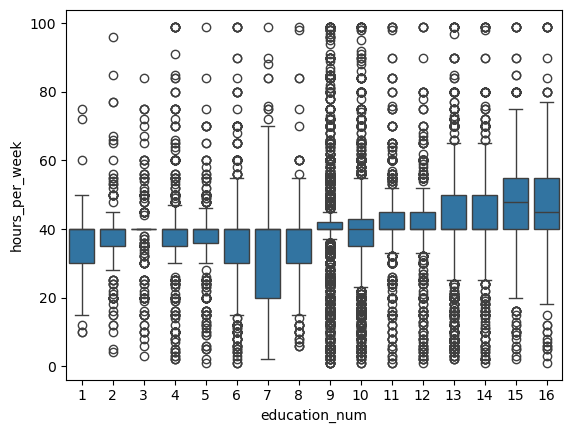

In [46]:
from scipy.stats import pearsonr
import seaborn as sns

corr, p_value = pearsonr(df["education_num"], df["hours_per_week"])
print(f"相关系数: {corr:.4f}")

plt.figure()
sns.boxplot(data=df, x="education_num", y="hours_per_week")
plt.show()

* 由此可见：学历越高，工作时长整体成上升趋势，但是相关系数很小，趋势不明显

### 婚姻状况与收入的关系

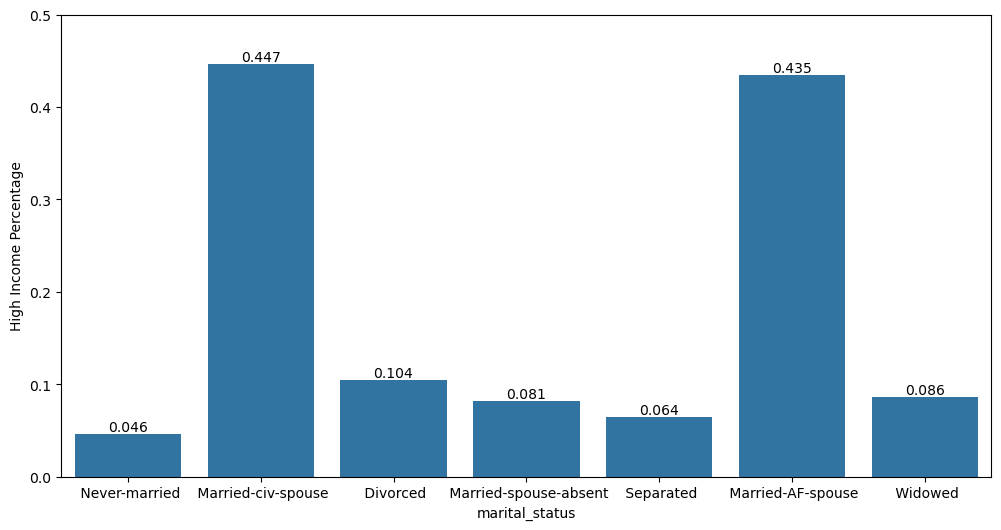

In [106]:
plt.figure(figsize=(12, 6))
df['if_high'] = (df['income'] == " >50K").astype(int)
sns.barplot(data=df, x='marital_status', y='if_high', errorbar=None)
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')
plt.ylim(0, 0.5)
plt.ylabel('High Income Percentage')
plt.show()

* 由此可见，收入水平与婚姻情况显著相关

## 进阶任务

In [147]:
from sklearn.tree import DecisionTreeRegressor

feature_columns = ['age', 'education_num', 'hours_per_week']  
target_column = 'if_high'  

X_train = df[feature_columns]
y_train = df[target_column]
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

test = pd.read_csv("test.csv")
X_test = test[feature_columns]
y_pred_dt = dt.predict(X_test)

y_result = y_pred_dt.round()
for y in y_result:
    print(int(y))

0
0
0
0
0
0
0
0
0
0
0
0
0
1
0
1
0
0
0
0
1
0
0
0
0
1
0
0
0
0
1
0
0
0
0
0
0
0
0
0
1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
0
0
1
0
0
0
0
0
1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
0
0
0
1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
0
0
0
0
0
0
1
0
0
1
0
0
0
1
0
0
1
0
0
0
1
0
0
0
0
1
0
0
1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
0
0
0
0
0
0
0
0
0
1
0
0
0
0
0
0
0
0
1
0
0
0
0
0
0
0
1
0
0
0
0
1
1
0
0
0
0
1
1
0
1
0
0
1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
0
1
1
0
0
1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
0
0
0
0
0
0
1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
0
0
0
0
0
0
0
0
0
0
0
0
0
1
0
0
0
0
0
0
1
0
0
1
1
0
0
0
0
0
0
0
0
1
0
0
1
0
0
0
1
1
0
0
1
0
0
0
0
0
0
0
0
1
0
0
0
0
1
0
0
0
0
0
0
0
0
0
0
1
1
0
1
0
0
0
1
0
0
1
0
1
1
0
0
0
0
0
1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
0
1
0
0
0
1
0
1
1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
0
1
0
0
0
0
0
0
1
0
0
0
0
0
0
1
1
0
0
0
1
0
0
1
0
0
0
0
0
1
0
0
0
0
0
0
0
0
0
0
0
0
0
1
0
0
1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
